# Build and train a decision tree model for classification tasks

## Data preprocessing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv("Social_Network_Ads.csv")
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
# Spliting the dataset into the training set and the test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [6]:
x_test[:5, :]

array([[   30, 87000],
       [   38, 50000],
       [   35, 75000],
       [   30, 79000],
       [   35, 50000]])

In [7]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

## Build and train model

In [8]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree_model.fit(x_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

## Predicting the test set results

In [9]:
y_pred = tree_model.predict(x_test_scaled)

In [10]:
np.concatenate((y_test.reshape(-1, 1), y_pred.reshape(-1, 1)), 1)[:10, :]

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0]])

## Model evaluation

The accuracy score of the Decision tree model is: 0.91


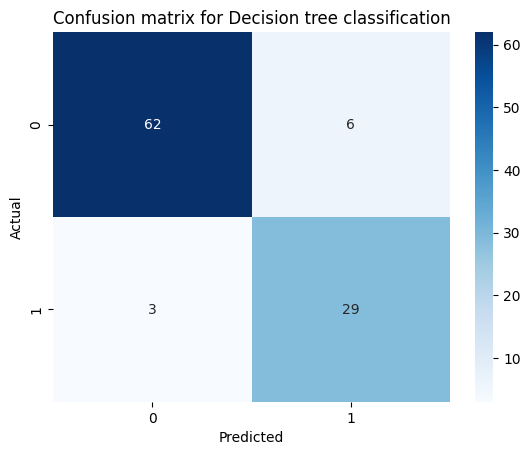

In [11]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

print(f"The accuracy score of the Decision tree model is: {accuracy_score(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
axe = sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion matrix for Decision tree classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

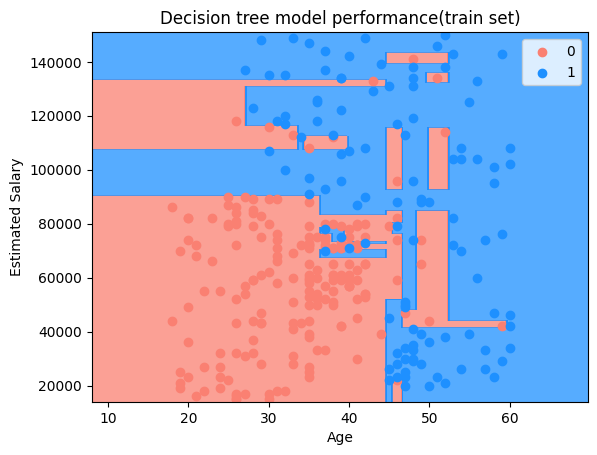

In [11]:
from matplotlib.colors import ListedColormap
X_set, y_set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-10 , stop=X_set[:, 0].max()+10, step=0.25),
                     np.arange(start=X_set[:, 1].min()-1000, stop=x[:, 1].max()+1000, step=0.25))
plt.contourf(X1, X2, tree_model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(("salmon", "dodgerblue")))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], color=ListedColormap(("salmon", "dodgerblue"))(i), label=j)

plt.title("Decision tree model performance(train set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()

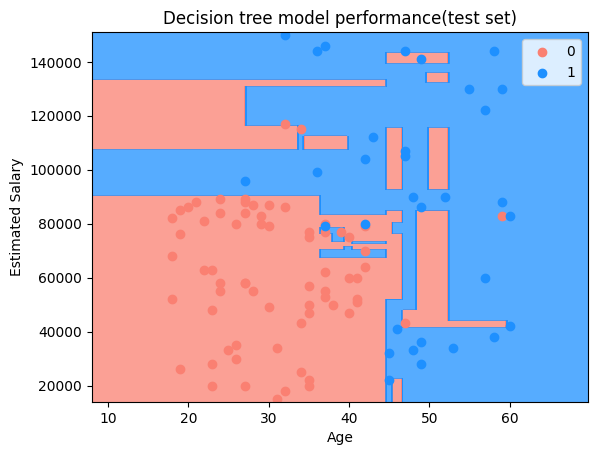

In [12]:
from matplotlib.colors import ListedColormap
X_set, y_set = x_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-10 , stop=X_set[:, 0].max()+10, step=0.25),
                     np.arange(start=X_set[:, 1].min()-1000, stop=x[:, 1].max()+1000, step=0.25))
plt.contourf(X1, X2, tree_model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(("salmon", "dodgerblue")))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], color=ListedColormap(("salmon", "dodgerblue"))(i), label=j)

plt.title("Decision tree model performance(test set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()